In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np

In [28]:
file = '../data/outs/all_time_cache.csv'

try:
    df = pd.read_csv(file, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo '{file}' não encontrado!")

Dados lidos com sucesso!


In [29]:
df.dtypes

nome           object
n               int64
m               int64
c               int64
fila           object
cpu_time        int64
wall_time       int64
l1              int64
l2              int64
llc             int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
rss             int64
branch_inst     int64
branch_miss     int64
dtype: object

In [30]:
df.head()

,nome,n,m,c,fila,cpu_time,wall_time,l1,l2,llc,cycles,inst,dtlb,page_faults,rss,branch_inst,branch_miss
0,GEN5,264346,1321730,500000,2LVBQ,232,232,0,0,0,0,0,0,0,60072,0,0
1,GEN5,264346,1321730,500000,2LVBQ,222,222,0,0,0,0,0,0,0,60116,0,0
2,GEN5,264346,1321730,500000,2LVBQ,229,229,0,0,0,0,0,0,0,60184,0,0
3,GEN5,264346,1321730,500000,2LVBQ,221,220,0,0,0,0,0,0,0,60440,0,0
4,GEN5,264346,1321730,500000,2LVBQ,220,220,0,0,0,0,0,0,0,60440,0,0


## Tempo de execução por quantidade de vértices

In [31]:
df_run_n = (
    df.groupby(['nome', 'fila'], as_index=False)
      .agg(run_mean=('wall_time', 'mean'),
           run_std=('wall_time', 'std'),
           run_var=('wall_time', 'var'))
)

df_merged = df.merge(df_run_n, on=['nome', 'fila'], how='left')
df_merged.head()

,nome,n,m,c,fila,cpu_time,wall_time,l1,l2,llc,cycles,inst,dtlb,page_faults,rss,branch_inst,branch_miss,run_mean,run_std,run_var
0,GEN5,264346,1321730,500000,2LVBQ,232,232,0,0,0,0,0,0,0,60072,0,0,222.5,4.648775,21.611111
1,GEN5,264346,1321730,500000,2LVBQ,222,222,0,0,0,0,0,0,0,60116,0,0,222.5,4.648775,21.611111
2,GEN5,264346,1321730,500000,2LVBQ,229,229,0,0,0,0,0,0,0,60184,0,0,222.5,4.648775,21.611111
3,GEN5,264346,1321730,500000,2LVBQ,221,220,0,0,0,0,0,0,0,60440,0,0,222.5,4.648775,21.611111
4,GEN5,264346,1321730,500000,2LVBQ,220,220,0,0,0,0,0,0,0,60440,0,0,222.5,4.648775,21.611111


In [32]:
df_run_n2 = df_merged[df_merged['fila'].isin(["BINH", "2LVBQDK"])]
df_run_n2

,nome,n,m,c,fila,cpu_time,wall_time,l1,l2,llc,cycles,inst,dtlb,page_faults,rss,branch_inst,branch_miss,run_mean,run_std,run_var
20,GEN5,264346,1321730,500000,2LVBQDK,207,207,0,0,0,0,0,0,0,62628,0,0,208.6,11.077505,122.711111
21,GEN5,264346,1321730,500000,2LVBQDK,206,206,0,0,0,0,0,0,0,62836,0,0,208.6,11.077505,122.711111
22,GEN5,264346,1321730,500000,2LVBQDK,205,205,0,0,0,0,0,0,0,62836,0,0,208.6,11.077505,122.711111
23,GEN5,264346,1321730,500000,2LVBQDK,203,203,0,0,0,0,0,0,0,63860,0,0,208.6,11.077505,122.711111
24,GEN5,264346,1321730,500000,2LVBQDK,212,212,0,0,0,0,0,0,0,63860,0,0,208.6,11.077505,122.711111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,GEN9,264346,1321730,705032590,BINH,263,263,0,0,0,0,0,0,0,71768,0,0,264.6,2.118700,4.488889
286,GEN9,264346,1321730,705032590,BINH,263,263,0,0,0,0,0,0,0,71768,0,0,264.6,2.118700,4.488889
287,GEN9,264346,1321730,705032590,BINH,263,263,0,0,0,0,0,0,0,71768,0,0,264.6,2.118700,4.488889
288,GEN9,264346,1321730,705032590,BINH,266,266,0,0,0,0,0,0,0,71768,0,0,264.6,2.118700,4.488889


In [33]:
df_pivot = df_run_n2.pivot_table(
    index=['nome', 'n', 'm', 'c'],          # linhas (ex: BAY, CAL, COL...)
    columns=['fila'],        # vira colunas (BINH, 2LVBQDK)
    values=['run_mean', 'run_std'] # valores que você quer
)

df_pivot

run_mean           run_std           
fila                           2LVBQDK   BINH    2LVBQDK       BINH
nome n      m       c                                              
GEN5 264346 1321730 500000       208.6  396.6  11.077505   6.186006
GEN6 264346 1321730 5000000      233.3  430.6   2.830391  46.850116
GEN7 264346 1321730 49999992     461.3  406.2  17.638657  17.655972
GEN8 264346 1321730 499999920   1262.3  254.6  16.048884   6.415260
GEN9 264346 1321730 705032590   1953.9  264.6  84.266047   2.118700

In [34]:

df_pivot = df_pivot.reset_index()
df_pivot['sqrt_c'] = df_pivot['c'].apply(math.sqrt)
df_pivot['log_n'] = df_pivot['n'].apply(math.log2)

# Razões — "quantas vezes maior"
df_pivot['sqrt_vs_log_ratio'] = df_pivot['sqrt_c'] / df_pivot['log_n']
df_pivot

nome       n        m          c run_mean           run_std             \
fila                                    2LVBQDK   BINH    2LVBQDK       BINH   
0     GEN5  264346  1321730     500000    208.6  396.6  11.077505   6.186006   
1     GEN6  264346  1321730    5000000    233.3  430.6   2.830391  46.850116   
2     GEN7  264346  1321730   49999992    461.3  406.2  17.638657  17.655972   
3     GEN8  264346  1321730  499999920   1262.3  254.6  16.048884   6.415260   
4     GEN9  264346  1321730  705032590   1953.9  264.6  84.266047   2.118700   

            sqrt_c      log_n sqrt_vs_log_ratio  
fila                                             
0       707.106781  18.012068         39.257390  
1      2236.067977  18.012068        124.142768  
2      7071.067246  18.012068        392.573871  
3     22360.677986  18.012068       1241.427582  
4     26552.449793  18.012068       1474.147768

In [35]:
latex = df_pivot.to_latex(
    index=False,
    column_format="|lrrrrrrr|",
    caption="Características dos grafos e tempo de execução do Dijkstra...",
    label="tab:res",
    float_format="%.1f"
)

print(latex)

\begin{table}
\caption{Características dos grafos e tempo de execução do Dijkstra...}
\label{tab:res}
\begin{tabular}{|lrrrrrrr|}
\toprule
nome & n & m & c & \multicolumn{2}{r}{run_mean} & \multicolumn{2}{r}{run_std} & sqrt_c & log_n & sqrt_vs_log_ratio \\
 &  &  &  & 2LVBQDK & BINH & 2LVBQDK & BINH &  &  &  \\
\midrule
GEN5 & 264346 & 1321730 & 500000 & 208.6 & 396.6 & 11.1 & 6.2 & 707.1 & 18.0 & 39.3 \\
GEN6 & 264346 & 1321730 & 5000000 & 233.3 & 430.6 & 2.8 & 46.9 & 2236.1 & 18.0 & 124.1 \\
GEN7 & 264346 & 1321730 & 49999992 & 461.3 & 406.2 & 17.6 & 17.7 & 7071.1 & 18.0 & 392.6 \\
GEN8 & 264346 & 1321730 & 499999920 & 1262.3 & 254.6 & 16.0 & 6.4 & 22360.7 & 18.0 & 1241.4 \\
GEN9 & 264346 & 1321730 & 705032590 & 1953.9 & 264.6 & 84.3 & 2.1 & 26552.4 & 18.0 & 1474.1 \\
\bottomrule
\end{tabular}
\end{table}



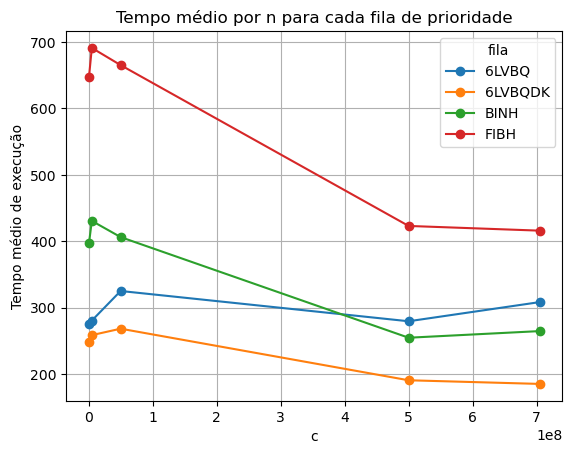

In [ ]:
df = df[df["fila"] != "2LVBQ"]
df = df[df["fila"] != "2LVBQDK"]

pivot = df.groupby(['c','fila'])['wall_time'].mean().unstack()

pivot.plot(marker='o')
plt.xlabel('c')
plt.ylabel('Tempo médio de execução')
plt.title('Tempo médio por C para cada fila de prioridade')
plt.grid(True)
plt.savefig('run_n.png', dpi=300, bbox_inches='tight')
plt.show()


## Correlação entre métricas e tempo de execução

In [37]:
df['l1_mr'] = df['l1'] / df['cycles']
df['l2_mr'] = df['l2'] / df['cycles']
df['llc_mr'] = df['llc'] / df['cycles']

In [38]:
df_run_miss = (
    df.groupby(['nome','fila'])[['wall_time','l1','l2','llc','cycles', 'inst', 'l1_mr', 'l2_mr', 'llc_mr']]
      .mean()
      .reset_index()
)

In [39]:
df_run_miss

,nome,fila,wall_time,l1,l2,llc,cycles,inst,l1_mr,l2_mr,llc_mr
0,GEN5,2LVBQ,222.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,GEN5,2LVBQDK,208.6,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,GEN5,6LVBQ,275.9,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,GEN5,6LVBQDK,247.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,GEN5,BINH,396.6,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
5,GEN5,FIBH,646.9,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
6,GEN6,2LVBQ,398.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
7,GEN6,2LVBQDK,233.3,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
8,GEN6,6LVBQ,280.4,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
9,GEN6,6LVBQDK,258.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
